# Predicting Irrigation Need: Gradient Boost Model
Lucas Calaff 
04/19/26

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder

from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
from sklearn.ensemble import GradientBoostingClassifier, HistGradientBoostingClassifier

## 1. Data importing and Cleaning 

In [53]:
Training_data = pd.read_csv("train.csv")
Training_data = Training_data.drop(columns=['id'])
Training_data.head()

,Soil_Type,Soil_pH,Soil_Moisture,Organic_Carbon,Electrical_Conductivity,Temperature_C,Humidity,Rainfall_mm,Sunlight_Hours,Wind_Speed_kmh,Crop_Type,Crop_Growth_Stage,Season,Irrigation_Type,Water_Source,Field_Area_hectare,Mulching_Used,Previous_Irrigation_mm,Region,Irrigation_Need
0,Loamy,4.92,32.58,1.01,3.05,15.01,50.61,725.99,5.90,16.79,Sugarcane,Sowing,Zaid,Drip,Rainwater,0.82,No,112.16,East,Low
1,Clay,7.08,56.61,0.44,2.00,22.92,67.86,985.66,6.98,3.39,Wheat,Vegetative,Kharif,Rainfed,River,5.27,Yes,47.16,South,Low
2,Clay,5.69,27.71,0.81,2.83,26.97,92.22,2201.70,6.05,3.85,Rice,Vegetative,Kharif,Sprinkler,Reservoir,8.24,Yes,110.38,North,Low
3,Sandy,5.65,13.32,1.33,0.87,13.32,61.57,1357.33,9.12,2.31,Wheat,Flowering,Kharif,Canal,River,8.32,Yes,53.85,South,Medium
4,Clay,7.96,59.14,0.38,0.96,20.22,91.11,1538.20,6.95,13.94,Wheat,Sowing,Rabi,Canal,River,7.37,No,93.19,South,Low


In [57]:
X = Training_data.drop('Irrigation_Need', axis=1)
y = Training_data['Irrigation_Need']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)
y_test_encoded = le.transform(y_test)

x_train_encoded = pd.get_dummies(X_train, drop_first=True)
x_test_encoded = pd.get_dummies(X_test, drop_first=True)

x_test_encoded = x_test_encoded.reindex(columns=x_train_encoded.columns, fill_value=0)

## 2. Gradient Boosted Model

In [58]:
# using the gradient boost classifer to train the model
gbc = GradientBoostingClassifier(random_state=42)

gbc.fit(x_train_encoded, y_train_encoded)
y_pred = gbc.predict(x_test_encoded)
print(classification_report(y_test_encoded, y_pred))
print(f1_score(y_test_encoded, y_pred, average='weighted'))

              precision    recall  f1-score   support

           0       0.97      0.89      0.93      4249
           1       0.99      1.00      0.99     73737
           2       0.98      0.98      0.98     48014

    accuracy                           0.98    126000
   macro avg       0.98      0.95      0.97    126000
weighted avg       0.98      0.98      0.98    126000

0.984539850088066


## 2.5. Trying HistaGradient Boosting to See if speeds are different 

In [59]:
# HistaGraident Boosting for the same dataset

HGBC = HistGradientBoostingClassifier(random_state=42)
HGBC.fit(x_train_encoded, y_train_encoded)
y_pred_hgbc = HGBC.predict(x_test_encoded)
print(classification_report(y_test_encoded, y_pred_hgbc))
print(f1_score(y_test_encoded, y_pred_hgbc, average='weighted'))

              precision    recall  f1-score   support

           0       0.93      0.91      0.92      4249
           1       0.99      0.99      0.99     73737
           2       0.98      0.97      0.98     48014

    accuracy                           0.98    126000
   macro avg       0.97      0.96      0.96    126000
weighted avg       0.98      0.98      0.98    126000

0.9831129416837849


Due to the increased performace in speed instead of using the origninal Gradient Model we will use histagradients to increase searching speeds espceilally when i comes to gridsearch

## 3. GridSearch for learning rate

In [60]:
# param grid for learning rate
param_grid_lr = {
    'learning_rate': [0.01, 0.1, 0.2, 0.3]
}
grid_search_lr = GridSearchCV(estimator= HGBC, param_grid=param_grid_lr, cv=5, scoring='f1_weighted', n_jobs=-1)
grid_search_lr.fit(x_train_encoded, y_train_encoded)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",HistGradientB...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'learning_rate': [0.01, 0.1, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1_weighted'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;- >3 : the fold and 

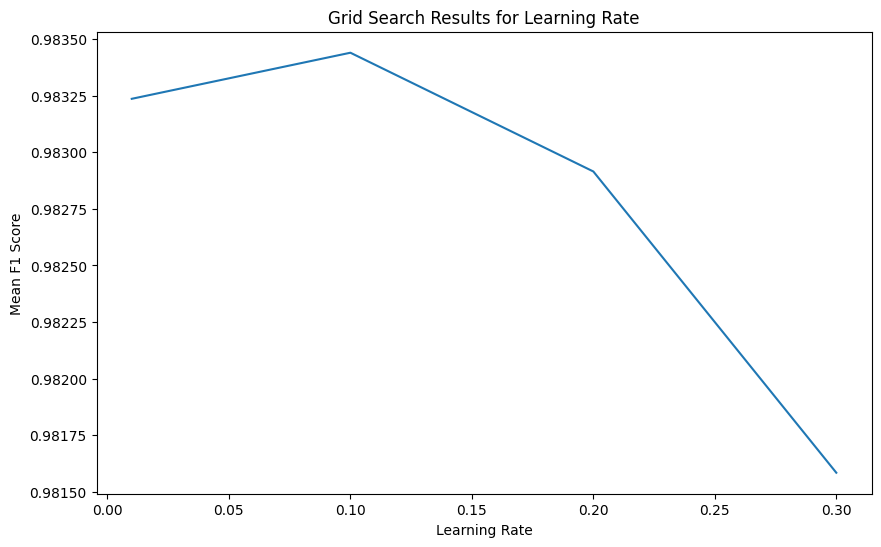

In [61]:
# Visualizing the results of the grid search for learning rate 

results_lr = pd.DataFrame(grid_search_lr.cv_results_)
plt.figure(figsize=(10, 6))
sns.lineplot(x='param_learning_rate', y='mean_test_score', data=results_lr)
plt.title('Grid Search Results for Learning Rate')
plt.xlabel('Learning Rate')
plt.ylabel('Mean F1 Score')
plt.show()

## 4. Grid Search for max leaf nodes

In [62]:
# param grid for max leaf nodes

param_grid_Max_leaf = {"max_leaf_nodes": [5,7, 10, 40 ]}

grid_search_Max_leaf = GridSearchCV(estimator= HGBC, param_grid=param_grid_Max_leaf, cv=5, scoring='f1_weighted', n_jobs=-1)
grid_search_Max_leaf.fit(x_train_encoded, y_train_encoded)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",HistGradientB...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_leaf_nodes': [5, 7, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1_weighted'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;- >3 : the fold and cand

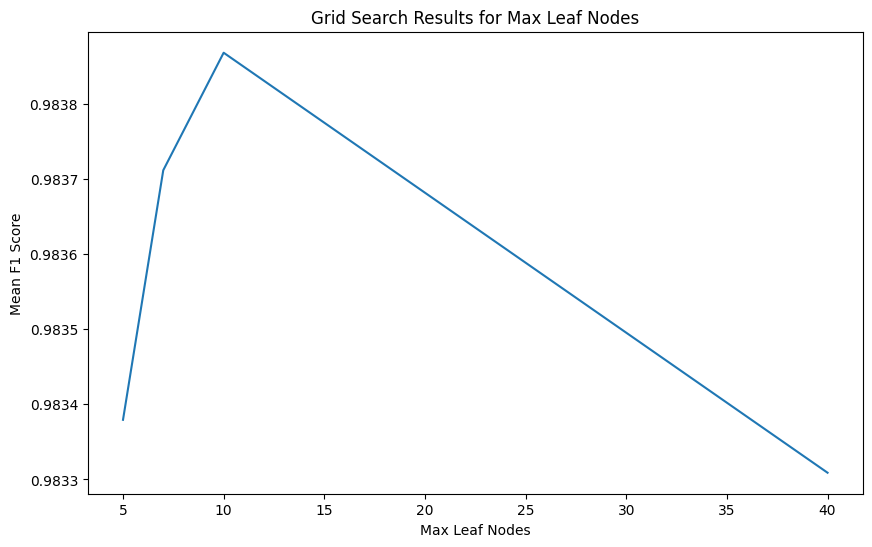

In [63]:
# visualizing the results of the grid search for max leaf nodes

results_Max_leaf = pd.DataFrame(grid_search_Max_leaf.cv_results_)
plt.figure(figsize=(10, 6))
sns.lineplot(x='param_max_leaf_nodes', y='mean_test_score', data=results_Max_leaf)
plt.title('Grid Search Results for Max Leaf Nodes')
plt.xlabel('Max Leaf Nodes')
plt.ylabel('Mean F1 Score')
plt.show()

## 5. Tuning min samples leaf 

In [64]:
# param grid for min samples leaf

param_grid_min = {"min_samples_leaf": [ 20, 50, 200, 500]}

grid_search_min = GridSearchCV(estimator= HGBC, param_grid=param_grid_min, cv=5, scoring='f1_weighted', n_jobs=-1)
grid_search_min.fit(x_train_encoded, y_train_encoded)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",HistGradientB...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'min_samples_leaf': [20, 50, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1_weighted'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;- >3 : the fold and 

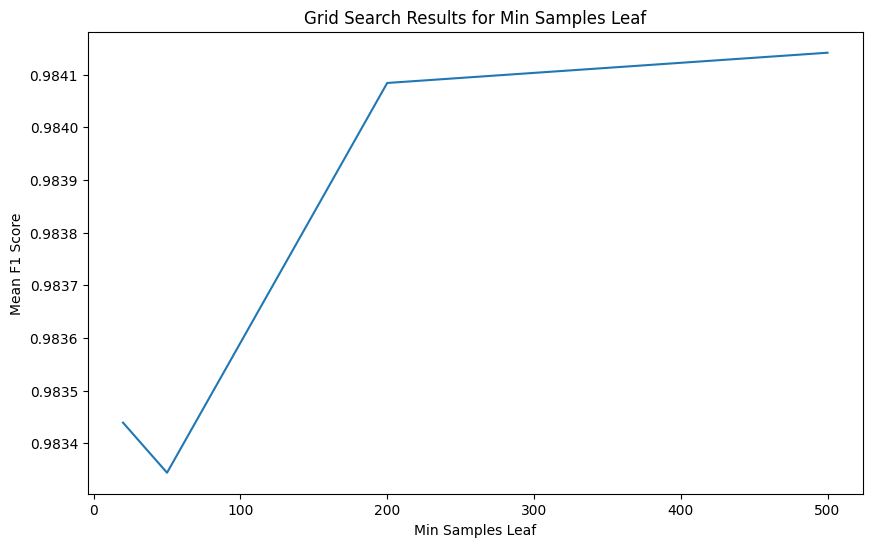

In [65]:
# visualizing the results of the grid search for min samples leaf

results_min = pd.DataFrame(grid_search_min.cv_results_)
plt.figure(figsize=(10, 6))
sns.lineplot(x='param_min_samples_leaf', y='mean_test_score', data=results_min)
plt.title('Grid Search Results for Min Samples Leaf')
plt.xlabel('Min Samples Leaf')
plt.ylabel('Mean F1 Score')
plt.show()

## 6. Combining all three searches to get the best model for Histagradient 

In [66]:
# making a model with the best parameters from the three grid searches

best_lr = grid_search_lr.best_params_['learning_rate']
best_max_leaf = grid_search_Max_leaf.best_params_['max_leaf_nodes']
best_min_samples_leaf = grid_search_min.best_params_['min_samples_leaf']

best_HGBC = HistGradientBoostingClassifier(random_state=42, learning_rate=best_lr, max_leaf_nodes=best_max_leaf, min_samples_leaf=best_min_samples_leaf)
best_HGBC.fit(x_train_encoded, y_train_encoded)
y_pred_best = best_HGBC.predict(x_test_encoded)
print(classification_report(y_test_encoded, y_pred_best))
print(f1_score(y_test_encoded, y_pred_best, average='weighted'))

              precision    recall  f1-score   support

           0       0.96      0.91      0.93      4249
           1       0.99      0.99      0.99     73737
           2       0.98      0.98      0.98     48014

    accuracy                           0.98    126000
   macro avg       0.98      0.96      0.97    126000
weighted avg       0.98      0.98      0.98    126000

0.9840390204834835


In [67]:
# showing the difference between the original HGBC and the best HGBC model

print("Original HGBC F1 Score:", f1_score(y_test_encoded, y_pred_hgbc, average='weighted'))
print("Best HGBC F1 Score:", f1_score(y_test_encoded, y_pred_best, average='weighted'))
print("Improvement in F1 Score:", f1_score(y_test_encoded, y_pred_best, average='weighted') - f1_score(y_test_encoded, y_pred_hgbc, average='weighted'))

Original HGBC F1 Score: 0.9831129416837849
Best HGBC F1 Score: 0.9840390204834835
Improvement in F1 Score: 0.0009260787996985265


## 7. Submission Output 

In [68]:
# generating the submission output for the best model

test_data = pd.read_csv("test.csv")
test_data_no_id = test_data.drop('id', axis=1)
test_data_encoded = pd.get_dummies(test_data_no_id, drop_first=True)
test_data_encoded = test_data_encoded.reindex(columns=x_train_encoded.columns, fill_value=0)

In [69]:
test_predictions = best_HGBC.predict(test_data_encoded)
submission = pd.DataFrame({
    'id': test_data['id'],
    'Irrigation_Need': le.inverse_transform(test_predictions)
})
submission.head(20)

,id,Irrigation_Need
0,630000,Low
1,630001,Low
2,630002,Low
3,630003,Low
4,630004,Low
5,630005,Medium
6,630006,Low
7,630007,Medium
8,630008,Medium
9,630009,Low


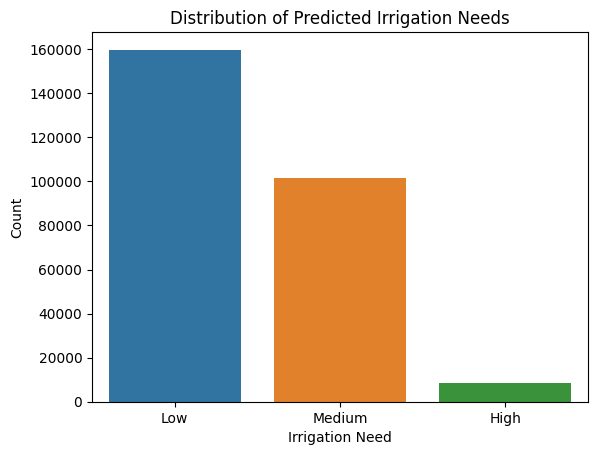

In [70]:
# visualizng our submission output

sns.countplot(x='Irrigation_Need', data=submission, hue='Irrigation_Need')
plt.title('Distribution of Predicted Irrigation Needs')
plt.xlabel('Irrigation Need')
plt.ylabel('Count')
plt.show()

In [52]:
# submission to csv
submission.to_csv('Hist_Grad_Boost_submission.csv', index=False)